In [1]:
# =========================================================
# SECTION 1: INSTALL REQUIRED LIBRARIES
# =========================================================
# We use SentenceTransformers to generate embeddings.
# sklearn is used for cosine similarity and visualization.
# matplotlib will help us visualize semantic space.

# !pip install sentence-transformers scikit-learn matplotlib

In [7]:
pip install sentence-transformers scikit-learn numpy matplotlib

  Using cached tokenizers-0.22.2-cp39-abi3-macosx_11_0_arm64.whl.metadata (7.3 kB)
  Using cached typer-0.24.1-py3-none-any.whl.metadata (16 kB)
  Using cached safetensors-0.7.0-cp38-abi3-macosx_11_0_arm64.whl.metadata (4.1 kB)
  Using cached fsspec-2026.2.0-py3-none-any.whl.metadata (10 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached click-8.3.1-py3-none-any.whl.metadata (2.6 kB)
  Using cached

In [8]:
# =========================================================
# SECTION 2: IMPORT REQUIRED LIBRARIES
# =========================================================

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
# =========================================================
# SECTION 3: CREATE A SMALL DOCUMENT DATASET
# =========================================================
# In a real system this would be thousands of documents.
# For demonstration we keep it small so results are easy to inspect.

documents = [
    "Affordable student housing near campus.",
    "Tips for renting apartments near university.",
    "University parking permit rules and regulations.",
    "Late assignment policy for the course.",
    "Campus dining hall hours and meal plans.",
    "How to repair a leaking faucet in an apartment.",
    "Best neighborhoods for graduate students.",
    "University library opening hours.",
]

In [10]:
# =========================================================
# SECTION 4: LOAD AN EMBEDDING MODEL
# =========================================================
# This model converts text into numerical vectors.
# Each sentence will become a vector in semantic space.

model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 13930.07it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [11]:
# =========================================================
# SECTION 5: GENERATE EMBEDDINGS FOR DOCUMENTS
# =========================================================
# We convert every document into a vector representation.

doc_embeddings = model.encode(documents)

print("Embedding shape:", doc_embeddings.shape)

# We now have 8 documents represented as 384-dimensional vectors.

Embedding shape: (8, 384)


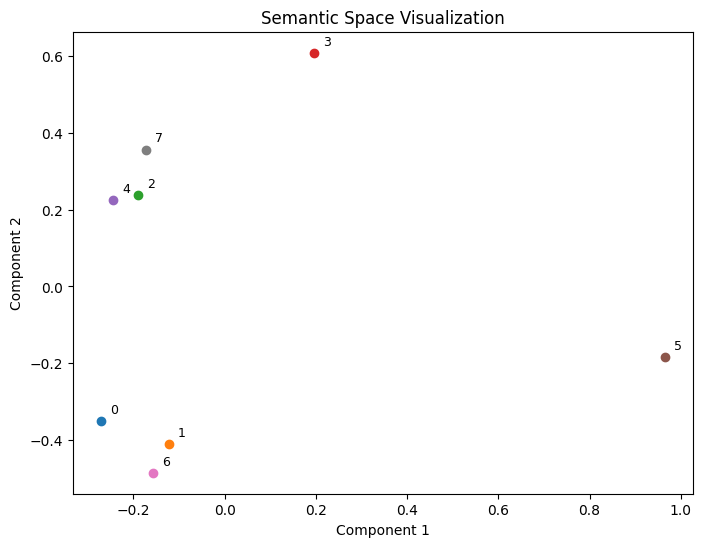

In [12]:
# =========================================================
# SECTION 6: VISUALIZE EMBEDDINGS IN 2D SPACE
# =========================================================
# Since humans cannot visualize 384 dimensions,
# we reduce them to 2D using PCA.

pca = PCA(n_components=2)
reduced_vectors = pca.fit_transform(doc_embeddings)

plt.figure(figsize=(8,6))

for i, text in enumerate(documents):
    x, y = reduced_vectors[i]
    plt.scatter(x, y)
    plt.text(x+0.02, y+0.02, str(i), fontsize=9)

plt.title("Semantic Space Visualization")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

In [13]:
# =========================================================
# SECTION 7: SEMANTIC SEARCH FUNCTION
# =========================================================
# This function converts a query into an embedding
# and finds the most similar documents.

def semantic_search(query, top_k=3):

    # Convert query to embedding
    query_embedding = model.encode([query])

    # Compute cosine similarity
    scores = cosine_similarity(query_embedding, doc_embeddings)[0]

    # Sort documents by similarity score
    top_indices = np.argsort(scores)[::-1][:top_k]

    print("\nQuery:", query)
    print("\nTop Results:\n")

    for idx in top_indices:
        print(f"Score: {scores[idx]:.3f} | Document: {documents[idx]}")

In [14]:
# =========================================================
# SECTION 8: TEST THE SEMANTIC SEARCH ENGINE
# =========================================================

semantic_search("cheap apartments near campus")


Query: cheap apartments near campus

Top Results:

Score: 0.814 | Document: Affordable student housing near campus.
Score: 0.758 | Document: Tips for renting apartments near university.
Score: 0.540 | Document: Best neighborhoods for graduate students.


In [ ]:
# =========================================================
# SECTION 9: SIMPLE INTERACTIVE SEARCH UI
#
# TRY THESE PROMPTS INDIVIDUALLY:

# student housing
# late assignment
# parking permit
# library hours
# =========================================================

while True:

    query = input("\nEnter your search query (or type 'exit'): ")

    if query.lower() == "exit":
        break

    semantic_search(query)

In [ ]:
# =========================================================
# SECTION 10: DOCUMENT CHUNKING
# =========================================================

long_document = """
Affordable apartments near campus are popular among students.
Rental prices vary depending on location and amenities.
Many students sign 12 month leases.
Parking availability varies across buildings.
"""

# simple chunking example
chunk_size = 100

chunks = [long_document[i:i+chunk_size] for i in range(0, len(long_document), chunk_size)]

print("Generated Chunks:\n")

for c in chunks:
    print("-", c)

Generated Chunks:

- 
Affordable apartments near campus are popular among students.
Rental prices vary depending on locat
- ion and amenities.
Many students sign 12 month leases.
Parking availability varies across buildings.
- 



In [ ]:
# =========================================================
# SECTION 11: INTERACTIVE SEMANTIC SPACE VISUALIZATION
# =========================================================
# =========================================================
# IMPORT INTERACTIVE TOOLS
# =========================================================

import ipywidgets as widgets
from IPython.display import display

In [ ]:
# =========================================================
# INTERACTIVE SEMANTIC SPACE VISUALIZATION
# =========================================================
# This function visualizes document embeddings in 2D space
# and places the query vector on the same map.

def visualize_query(query):

    query_embedding = model.encode([query])

    # Combine embeddings
    combined = np.vstack([doc_embeddings, query_embedding])

    # Reduce dimensions
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(combined)

    doc_points = reduced[:-1]
    query_point = reduced[-1]

    plt.figure(figsize=(8,6))

    # Plot documents
    plt.scatter(doc_points[:,0], doc_points[:,1], color='blue')

    for i, doc in enumerate(documents):
        plt.text(doc_points[i,0]+0.02, doc_points[i,1]+0.02, str(i))

    # Plot query
    plt.scatter(query_point[0], query_point[1], color='red', marker='*', s=250)
    plt.text(query_point[0]+0.02, query_point[1]+0.02, "Query")

    plt.title("Semantic Space Visualization")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")

    plt.show()

# Where do you think the query cheap apartments near campus will land?

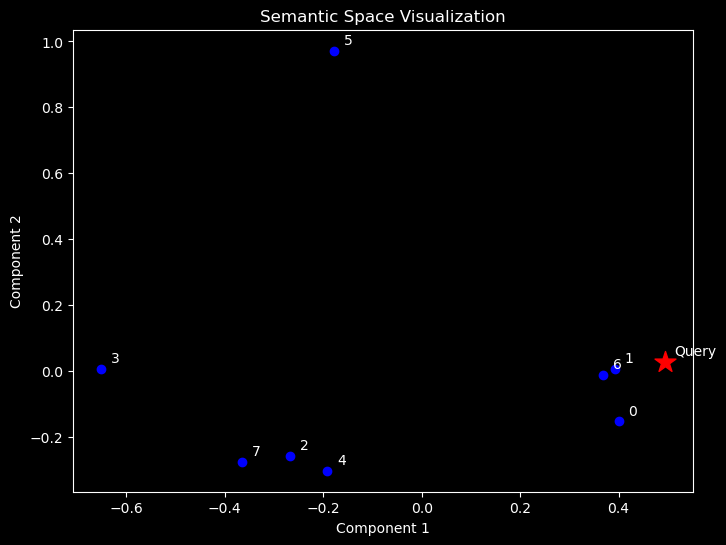

In [ ]:
# =========================================================
# QUERY INPUT WIDGET

# TRY THESE PROMPTS INDIVIDUALLY:

# student housing
# late assignment
# parking permit
# library hours

# =========================================================

visualize_query("cheap apartments near campus")

In [ ]:
# =========================================================
# INTERACTIVE SEMANTIC SPACE VISUALIZATION
# =========================================================
# This function visualizes document embeddings in 2D space
# and places the query vector on the same map.

# =========================================================
# ADVANCED SEMANTIC SPACE VISUALIZATION
# =========================================================

def visualize_query_with_neighbors(query, top_k=3):

    # Generate query embedding
    query_embedding = model.encode([query])

    # Compute cosine similarity
    scores = cosine_similarity(query_embedding, doc_embeddings)[0]

    # Get top-k neighbors
    top_indices = np.argsort(scores)[::-1][:top_k]

    # Combine embeddings for PCA
    combined = np.vstack([doc_embeddings, query_embedding])

    pca = PCA(n_components=2)
    reduced = pca.fit_transform(combined)

    doc_points = reduced[:-1]
    query_point = reduced[-1]

    plt.figure(figsize=(9,7))

    # Plot all documents
    plt.scatter(doc_points[:,0], doc_points[:,1], color='lightgray', label="Documents")

    # Highlight nearest neighbors
    for idx in top_indices:
        plt.scatter(doc_points[idx,0], doc_points[idx,1], color='blue', s=120)

        plt.text(
            doc_points[idx,0]+0.02,
            doc_points[idx,1]+0.02,
            f"{scores[idx]:.2f}",
            fontsize=10
        )

    # Plot query
    plt.scatter(query_point[0], query_point[1], color='red', marker='*', s=350, label="Query")

    plt.text(query_point[0]+0.02, query_point[1]+0.02, "Query", fontsize=12)

    plt.title("Semantic Search Visualization")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")

    plt.legend()

    plt.show()

    # Print results
    print("\nTop Results:\n")

    for idx in top_indices:
        print(f"{scores[idx]:.3f} → {documents[idx]}")

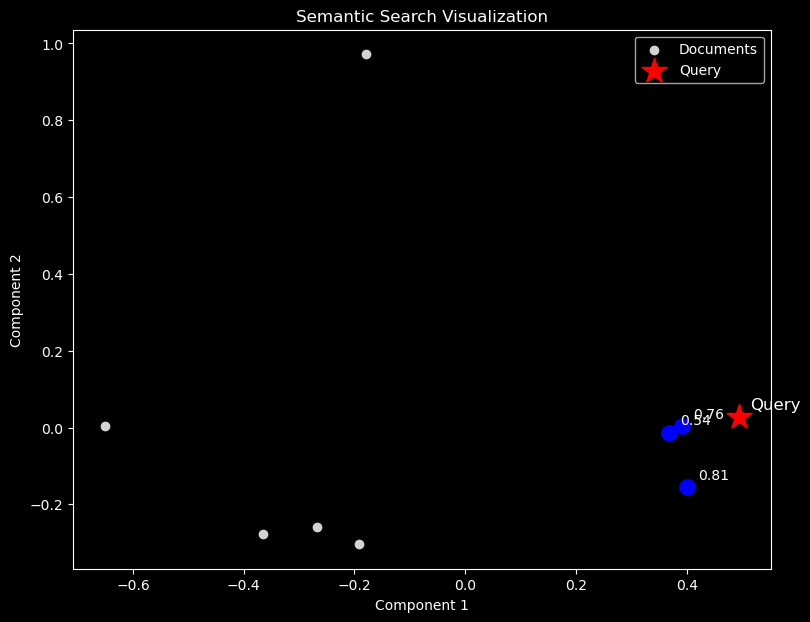


Top Results:

0.814 → Affordable student housing near campus.
0.758 → Tips for renting apartments near university.
0.540 → Best neighborhoods for graduate students.


In [ ]:
visualize_query_with_neighbors("cheap apartments near campus")